In [1]:
!pip install torch transformers scikit-learn pandas tqdm

In [2]:
!pip install git+https://github.com/trent-b/iterative-stratification.git

  Cloning https://github.com/trent-b/iterative-stratification.git to /tmp/pip-req-build-pqa48ksu
  Running command git clone --filter=blob:none --quiet https://github.com/trent-b/iterative-stratification.git /tmp/pip-req-build-pqa48ksu
  Resolved https://github.com/trent-b/iterative-stratification.git to commit c763bd5440e5f03c6447471305897c1046fc4838
  Preparing metadata (setup.py) ... done
  Created wheel for iterative-stratification: filename=iterative_stratification-0.1.9-py3-none-any.whl size=8444 sha256=184680151c0694fecc62a152686f2734cef32e465c6e462faae9a895cfb59b19
  Stored in directory: /tmp/pip-ephem-wheel-cache-27lk8w6_/wheels/1a/53/b5/f5f9836cdfff718e36f6af0df976157168f38b5ce6bf53a49d
Successfully built iterative-stratification


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoConfig, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import AdamW
from tqdm import tqdm
import os
from google.colab import files
import random

In [4]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

In [5]:
uploaded = files.upload()

Saving unified_emotion_dataset.csv to unified_emotion_dataset.csv


In [6]:
# ----------------------
# 1. Load CSV
# ----------------------
df = pd.read_csv("unified_emotion_dataset.csv")
df = df.sample(frac=1).reset_index(drop=True)

# Get emotion columns (excluding 'text')
emotion_cols = df.columns[1:]  # adjust if your labels start elsewhere

# Extract texts and labels
texts = df['text'].values
labels = df[df.columns[1:]].values  # after 9th col are binary emotions
label_names = df.columns[1:].tolist()
num_labels = len(label_names)

# Tokenizer
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

#tae898/emoberta-base

# Add extra columns: word count and token count
def count_words_and_tokens(text):
    words = len(text.split())
    tokens = len(tokenizer.encode(text, add_special_tokens=True))
    return words, tokens

df_count = df[["text"]].copy()
df_count[["word_count", "token_count"]] = df["text"].apply(
    lambda x: pd.Series(count_words_and_tokens(x))
)

print("Sample rows with new columns:")
print(df.head())

# Class distribution
label_counts = np.sum(labels, axis=0)
print("Class distribution (counts per label):")
for name, c in zip(label_names, label_counts):
    print(f"{name}: {c}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1437 > 512). Running this sequence through the model will result in indexing errors


Sample rows with new columns:
                                                text  admiration  amusement  \
0  Not entirely sure what happened in that movie ...           0          0   
1               Still waiting to hear back from them           0          0   
2  Everything about this party is fairly delightf...           0          0   
3  It's probably an obvious answer, but it's bad ...           0          0   
4  Feeling extremely hurt after his thoughtless w...           0          0   

   anger  anxiety/nervousness  approval  caring  confusion  curiosity  desire  \
0      0                    0         0       0          1          0       0   
1      0                    0         0       0          0          0       0   
2      0                    0         0       0          0          0       0   
3      0                    0         1       0          0          0       0   
4      0                    0         0       0          0          0       0   

   ...  

In [7]:
print(df.columns)

Index(['text', 'admiration', 'amusement', 'anger', 'anxiety/nervousness',
       'approval', 'caring', 'confusion', 'curiosity', 'desire',
       'disappointment', 'disapproval', 'disgust', 'embarrassment/shame',
       'excitement', 'fear', 'annoyance/frustration', 'gratitude',
       'guilt/remorse', 'happiness', 'hope', 'jealousy', 'loneliness', 'love',
       'neutral', 'optimism', 'pride', 'realization', 'relief', 'sadness',
       'surprise'],
      dtype='object')


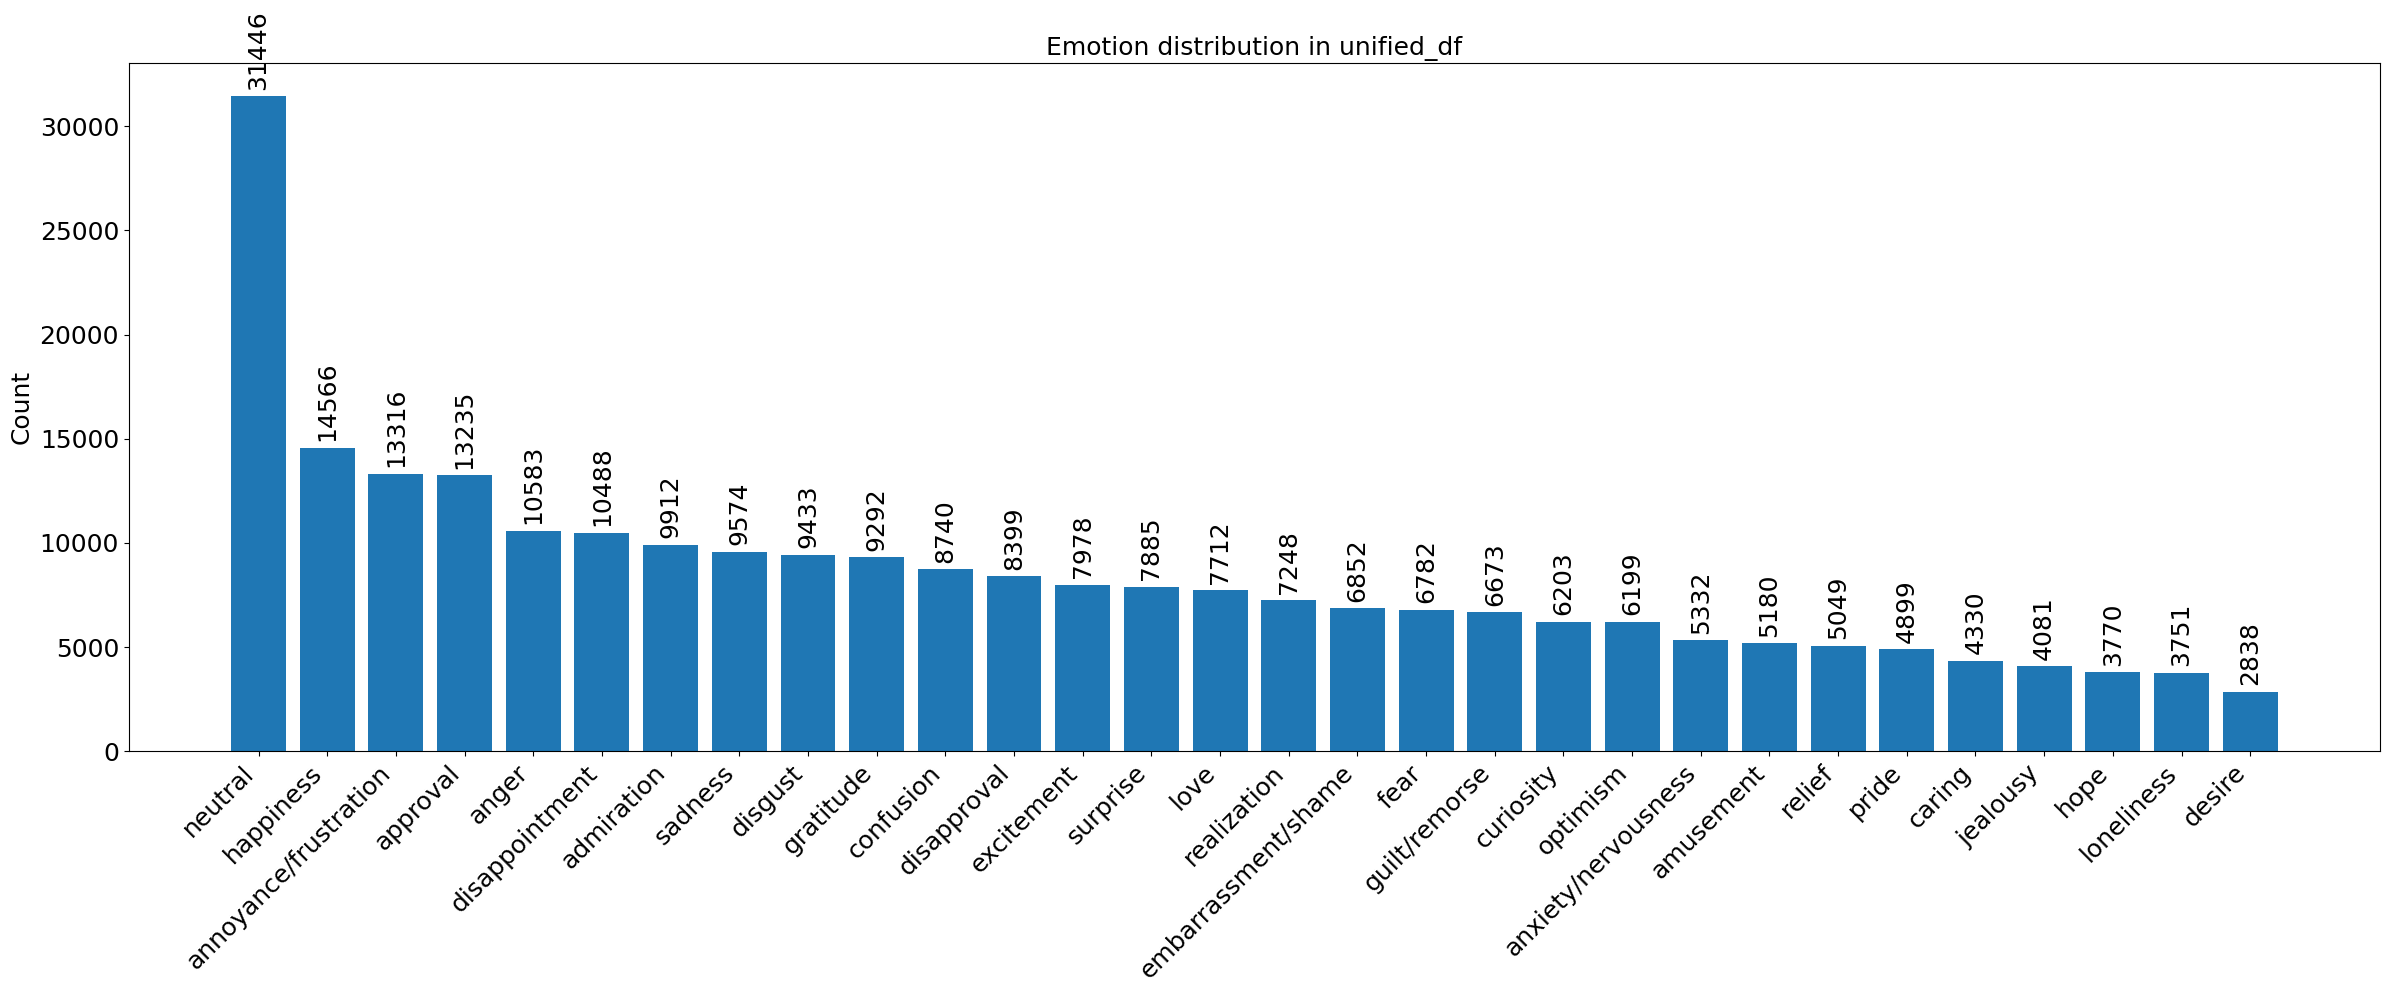

In [8]:
import matplotlib.pyplot as plt

emotion_counts = df.drop(columns=["text"]).sum().sort_values(ascending=False)

plt.figure(figsize=(24,10))
plt.bar(emotion_counts.index, emotion_counts.values)

# numbers slightly above bars
offset = emotion_counts.max() * 0.01
for i, v in enumerate(emotion_counts.values):
    plt.text(i, v + offset, str(int(v)), ha='center', va='bottom', rotation=90, fontsize=18)

plt.xticks(rotation=45, ha='right', fontsize=18)
plt.yticks(fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("Emotion distribution in unified_df", fontsize=18)

plt.tight_layout()
plt.show()


In [9]:
print("Total number of emotion labels:", num_labels)
print("Max token count:",max(df_count["token_count"]))
print("Max word count:", max(df_count["word_count"]))
print()
second_max_token = df_count["token_count"].nlargest(2).iloc[-1]
print("second_max_token:",second_max_token)

third_max_token = df_count["token_count"].nlargest(3).iloc[-1]
print("third_max_token:",third_max_token)

fourth_max_token = df_count["token_count"].nlargest(4).iloc[-1]
print("fourth_max_token:",fourth_max_token)

fifth_max_token = df_count["token_count"].nlargest(5).iloc[-1]
print("fifth_max_token:",fifth_max_token)

tenth_max_token = df_count["token_count"].nlargest(10).iloc[-1]
print("tenth_max_token:",tenth_max_token)

twentieth_max_token = df_count["token_count"].nlargest(20).iloc[-1]
print("twentieth_max_token:",twentieth_max_token)

hundredth_max_token = df_count["token_count"].nlargest(100).iloc[-1]
print("hundredth_max_token:",hundredth_max_token)


Total number of emotion labels: 30
Max token count: 1437
Max word count: 178

second_max_token: 320
third_max_token: 228
fourth_max_token: 224
fifth_max_token: 211
tenth_max_token: 167
twentieth_max_token: 137
hundredth_max_token: 92


In [10]:
class UnifiedDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': label
        }

In [11]:
# Train/Val/Test split
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(msss.split(texts, labels))
texts_train, texts_test = texts[train_idx], texts[test_idx]
labels_train, labels_test = labels[train_idx], labels[test_idx]

msss_val = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, val_idx = next(msss_val.split(texts_train, labels_train))
texts_train, texts_val = texts_train[train_idx], texts_train[val_idx]
labels_train, labels_val = labels_train[train_idx], labels_train[val_idx]

train_dataset = UnifiedDataset(texts_train, labels_train, tokenizer)
val_dataset = UnifiedDataset(texts_val, labels_val, tokenizer)
test_dataset = UnifiedDataset(texts_test, labels_test, tokenizer)

def collate_fn(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

print("Train size:", len(texts_train))
print("Val size:", len(texts_val))
print("Test size:", len(texts_test))

Train size: 104162
Val size: 11547
Test size: 29065


In [12]:
import pandas as pd

emotion_names = df.columns[1:]  # or list of your emotion columns

train_counts = pd.Series(labels_train.sum(axis=0), index=emotion_names)
val_counts   = pd.Series(labels_val.sum(axis=0), index=emotion_names)
test_counts  = pd.Series(labels_test.sum(axis=0), index=emotion_names)

print("TRAIN\n", train_counts.sort_values(ascending=False))
print("\nVAL\n", val_counts.sort_values(ascending=False))
print("\nTEST\n", test_counts.sort_values(ascending=False))


TRAIN
 neutral                  22641
happiness                10488
annoyance/frustration     9588
approval                  9529
anger                     7619
disappointment            7551
admiration                7137
sadness                   6893
disgust                   6791
gratitude                 6691
confusion                 6293
disapproval               6047
excitement                5744
surprise                  5677
love                      5553
realization               5218
embarrassment/shame       4934
fear                      4883
guilt/remorse             4804
curiosity                 4466
optimism                  4463
anxiety/nervousness       3839
amusement                 3730
relief                    3635
pride                     3527
caring                    3118
jealousy                  2938
hope                      2714
loneliness                2701
desire                    2043
dtype: int64

VAL
 neutral                  2516
happiness     

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.25, reduction='mean'):
        """
        alpha : weighting factor for positive vs negative class
        gamma : focusing parameter to reduce loss for well-classified examples
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        """
        logits : raw model outputs (before sigmoid)
        targets: binary labels (0/1), same shape as logits
        """
        probs = torch.sigmoid(logits)
        ce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = probs * targets + (1 - probs) * (1 - targets)
        loss = self.alpha * (1 - p_t) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


In [14]:
# Model setup
device = (
    torch.device("cuda") if torch.cuda.is_available() else
    torch.device("xla") if "xla" in torch.backends.__dict__ and torch.backends.xla.is_available() else
    torch.device("cpu")
)

config = AutoConfig.from_pretrained(
    model_name,
    num_labels=num_labels,
    problem_type="multi_label_classification",
    dropout = 0.05
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    config=config,
    ignore_mismatched_sizes=True
)

model.to(device)

epochs = 5
optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=0.1)
criterion = FocalLoss(alpha=1, gamma=2.25, reduction='mean')

num_training_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * num_training_steps), num_training_steps=num_training_steps)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
# Training + Validation loop

best_val_f1 = 0.0
best_model_state = None

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # --------------------
    # Training
    # --------------------
    model.train()
    train_loss = 0
    train_preds = []
    train_true = []

    for batch in tqdm(train_loader):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

        # Collect predictions and true labels for metrics
        train_preds.extend(torch.sigmoid(logits).detach().cpu().numpy())
        train_true.extend(labels.detach().cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)

    # Convert probabilities to binary using 0.5
    train_preds_bin = (np.array(train_preds) >= 0.5).astype(int)

    # Compute training metrics
    train_acc = accuracy_score(train_true, train_preds_bin)
    train_f1_micro = f1_score(train_true, train_preds_bin, average="micro")
    train_f1_macro = f1_score(train_true, train_preds_bin, average="macro")
    train_precision = precision_score(train_true, train_preds_bin, average="micro", zero_division=0)
    train_recall = recall_score(train_true, train_preds_bin, average="micro", zero_division=0)

    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Train F1 (micro): {train_f1_micro:.4f} | Train F1 (macro): {train_f1_macro:.4f} | "
          f"Train Precision: {train_precision:.4f} | Train Recall: {train_recall:.4f}")

    # --------------------
    # Validation
    # --------------------
    model.eval()
    val_loss = 0
    val_preds = []
    val_true = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = criterion(logits, labels)
            val_loss += loss.item()

            val_preds.extend(torch.sigmoid(logits).cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)

    # Convert probabilities to binary using 0.5
    val_preds_bin = (np.array(val_preds) >= 0.5).astype(int)

    # Compute validation metrics
    val_acc = accuracy_score(val_true, val_preds_bin)
    val_f1_micro = f1_score(val_true, val_preds_bin, average="micro")
    val_f1_macro = f1_score(val_true, val_preds_bin, average="macro")
    val_precision = precision_score(val_true, val_preds_bin, average="micro", zero_division=0)
    val_recall = recall_score(val_true, val_preds_bin, average="micro", zero_division=0)

    print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Val F1 (micro): {val_f1_micro:.4f} | Val F1 (macro): {val_f1_macro:.4f} | "
          f"Val Precision: {val_precision:.4f} | Val Recall: {val_recall:.4f}")

    # Save best model
    if val_f1_micro > best_val_f1:
        best_val_f1 = val_f1_micro
        best_model_state = model.state_dict()

# Load best model after all epochs
model.load_state_dict(best_model_state)
print(f"\nBest validation F1 (micro) after {epochs} epochs: {best_val_f1:.4f}")


Epoch 1/5


100%|██████████| 6511/6511 [29:48<00:00,  3.64it/s]


Train Loss: 0.0301 | Train Acc: 0.4015 | Train F1 (micro): 0.4975 | Train F1 (macro): 0.4773 | Train Precision: 0.6049 | Train Recall: 0.4225
Val Loss: 0.0216 | Val Acc: 0.5563 | Val F1 (micro): 0.6512 | Val F1 (macro): 0.6316 | Val Precision: 0.7907 | Val Recall: 0.5535

Epoch 2/5


100%|██████████| 6511/6511 [29:48<00:00,  3.64it/s]


Train Loss: 0.0201 | Train Acc: 0.5580 | Train F1 (micro): 0.6653 | Train F1 (macro): 0.6509 | Train Precision: 0.7970 | Train Recall: 0.5710
Val Loss: 0.0204 | Val Acc: 0.5733 | Val F1 (micro): 0.6658 | Val F1 (macro): 0.6510 | Val Precision: 0.7998 | Val Recall: 0.5702

Epoch 3/5


...

Train Loss: 0.0179 | Train Acc: 0.5909 | Train F1 (micro): 0.7008 | Train F1 (macro): 0.6928 | Train Precision: 0.8117 | Train Recall: 0.6166
Val Loss: 0.0201 | Val Acc: 0.5844 | Val F1 (micro): 0.6813 | Val F1 (macro): 0.6782 | Val Precision: 0.7779 | Val Recall: 0.6060

Epoch 4/5


100%|██████████| 6511/6511 [29:49<00:00,  3.64it/s]


Train Loss: 0.0159 | Train Acc: 0.6166 | Train F1 (micro): 0.7322 | Train F1 (macro): 0.7288 | Train Precision: 0.8255 | Train Recall: 0.6578
Val Loss: 0.0203 | Val Acc: 0.5834 | Val F1 (micro): 0.6847 | Val F1 (macro): 0.6850 | Val Precision: 0.7468 | Val Recall: 0.6321

Epoch 5/5


100%|██████████| 6511/6511 [29:48<00:00,  3.64it/s]


Train Loss: 0.0141 | Train Acc: 0.6401 | Train F1 (micro): 0.7603 | Train F1 (macro): 0.7609 | Train Precision: 0.8391 | Train Recall: 0.6950
Val Loss: 0.0211 | Val Acc: 0.5922 | Val F1 (micro): 0.6884 | Val F1 (macro): 0.6878 | Val Precision: 0.7559 | Val Recall: 0.6320

Best validation F1 (micro) after 5 epochs: 0.6884


In [16]:
model.eval()
test_preds, test_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        test_preds.extend(torch.sigmoid(logits).cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_preds = (torch.tensor(np.array(test_preds)) >= 0.5).int()
test_labels = torch.tensor(np.array(test_labels)).int()
test_acc = accuracy_score(test_labels, test_preds)
test_micro_f1 = f1_score(test_labels, test_preds, average='micro')
test_macro_f1 = f1_score(test_labels, test_preds, average='macro')
print(f"Test Acc: {test_acc:.4f}, Test Micro F1: {test_micro_f1:.4f}, Test Macro F1: {test_macro_f1:.4f}")
test_precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
test_recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
print(f"Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}")
cm = confusion_matrix(test_labels.view(-1), test_preds.view(-1))
print("Confusion Matrix (flattened across all labels):")
print(cm)

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names, zero_division=0))


Test Acc: 0.5877, Test Micro F1: 0.6892, Test Macro F1: 0.6907
Test Precision: 0.7546, Test Recall: 0.6343
Confusion Matrix (flattened across all labels):
[[811215  10385]
 [ 18414  31936]]

Detailed Classification Report:
                       precision    recall  f1-score   support

           admiration       0.73      0.66      0.69      1982
            amusement       0.80      0.70      0.75      1036
                anger       0.67      0.60      0.63      2117
  anxiety/nervousness       0.75      0.64      0.69      1066
             approval       0.56      0.36      0.44      2647
               caring       0.54      0.42      0.47       866
            confusion       0.75      0.66      0.70      1748
            curiosity       0.69      0.68      0.68      1241
               desire       0.58      0.34      0.43       568
       disappointment       0.66      0.45      0.54      2098
          disapproval       0.54      0.42      0.48      1680
              disgus

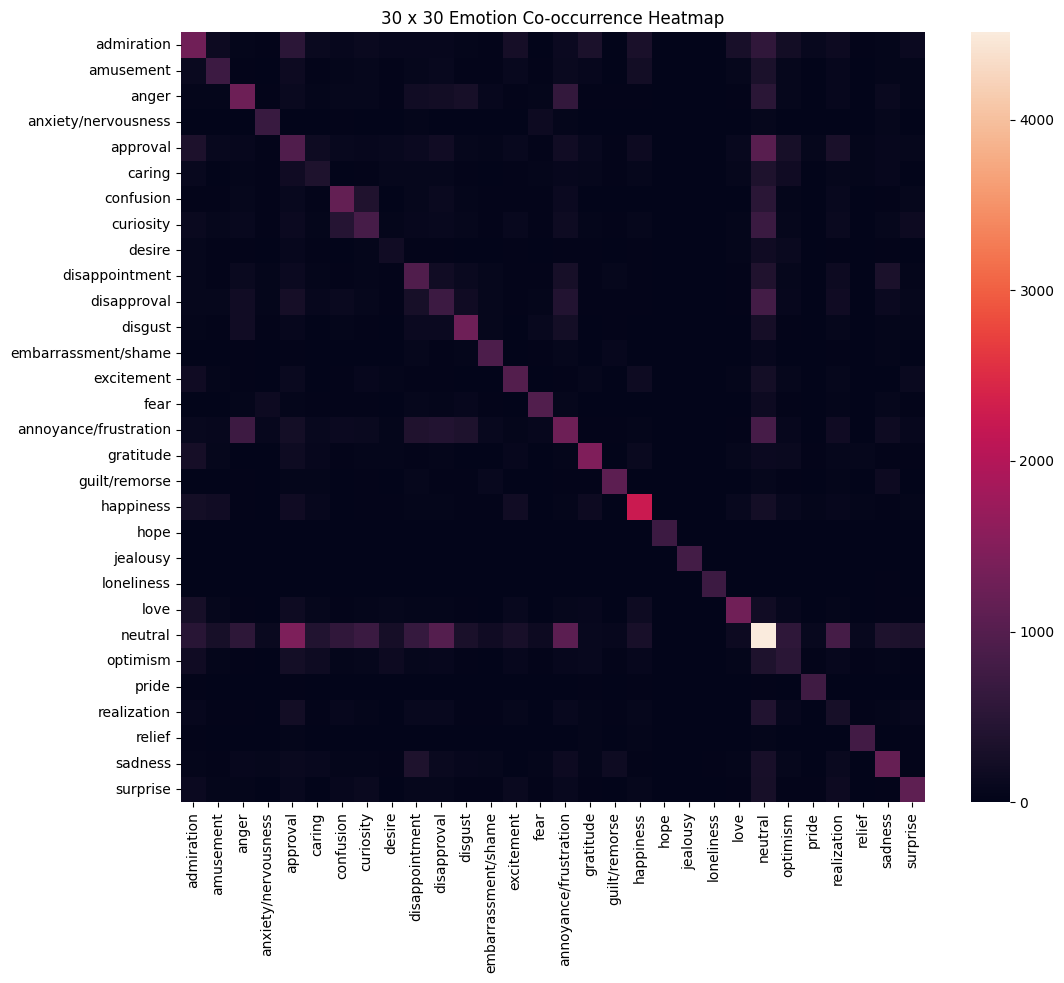

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(test_labels.numpy(), test_preds.numpy())

# sum across TN/FP/FN/TP if you want a 27 x 27 style heatmap of co-predictions
heatmap_data = np.zeros((30, 30))
for i in range(30):
    for j in range(30):
        # approximate co-occurrence in predictions vs true
        heatmap_data[i, j] = ((test_preds[:, i] == 1) & (test_labels[:, j] == 1)).sum()

plt.figure(figsize=(12,10))
sns.heatmap(heatmap_data, xticklabels=label_names, yticklabels=label_names, cmap='rocket', annot=False)
plt.title("30 x 30 Emotion Co-occurrence Heatmap")
plt.show()


In [33]:
# Prediction function
def predict_emotions(text, top_k=5):
    model.eval()
    encoding = tokenizer(text, truncation=True, padding='max_length', max_length=128, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**encoding)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]
    top_indices = probs.argsort()[-top_k:][::-1]
    return [(label_names[i], float(probs[i])) for i in top_indices]

user_text = input("Enter a text: ")
print("\nUser Input:", user_text)
print("Predicted Emotions:")
for label, score in predict_emotions(user_text):
    print(f"{label}: {score:.4f}")

Enter a text: you know you can tell me anything

User Input: you know you can tell me anything
Predicted Emotions:
neutral: 0.7363
approval: 0.5299
curiosity: 0.3131
optimism: 0.3111
realization: 0.3006


In [ ]:
u know whatever may happen, i will always be with you
ahh now i can rest
after i got outta the restroom, those bullies humiliated me
whatever may happen, whatever things may go throguh, we always have a choice, my friend harry thoguht me that, its the choices that makes us who we are, and we can always make the right choice
I kept replaying that moment in my head all night — the way they smiled at me like I mattered and then walked away without looking back — and now I can’t tell if I’m feeling grateful for having experienced something real at all, hurt that it ended so quietly, anxious that I’ll never feel that depth again, or strangely hopeful that maybe this ache means I’m still capable of loving deeply.
After working so hard for something I thought would finally prove I was enough, I stood there holding the result in my hands, feeling proud that I made it this far, disappointed that it didn’t feel as fulfilling as I imagined, scared that maybe nothing ever will, and quietly wondering whether this emptiness is just a phase or a sign that I need to change the direction of my life.


In [19]:
# Save & download model
model.save_pretrained("unified_roberta")
tokenizer.save_pretrained("unified_roberta")
!zip -r unified_roberta.zip unified_roberta
files.download("unified_roberta.zip")
# Reload model from uploaded zip
# uploaded = files.upload()
# !unzip -o unified_roberta.zip -d ./
# loaded_model = RobertaForSequenceClassification.from_pretrained("unified_roberta")
# loaded_tokenizer = RobertaTokenizer.from_pretrained("unified_roberta")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: unified_roberta/ (stored 0%)
  adding: unified_roberta/config.json (deflated 66%)
  adding: unified_roberta/model.safetensors (deflated 9%)
  adding: unified_roberta/tokenizer_config.json (deflated 50%)
  adding: unified_roberta/tokenizer.json (deflated 82%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Testing with raw user input

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# Path to your extracted model
model_path = "D:\\Emotion Detection Project\\individual Experiment Implementation 5\\Unified_Dataset_RoBERTa_Model_lr3e_5_5epochs_0_1dropout\\unified_roberta"

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.eval()

# Emotion labels (same order as training)
labels = [
"admiration","amusement","anger","anxiety/nervousness","approval","caring",
"confusion","curiosity","desire","disappointment","disapproval","disgust",
"embarrassment/shame","excitement","fear","annoyance/frustration","gratitude",
"guilt/remorse","happiness","hope","jealousy","loneliness","love","neutral",
"optimism","pride","realization","relief","sadness","surprise"
]

def predict_top5(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probs = F.softmax(logits, dim=1)

    top_probs, top_indices = torch.topk(probs, 5)

    print("\nTop 5 Predicted Emotions:\n")

    for i in range(5):
        emotion = labels[top_indices[0][i].item()]
        confidence = top_probs[0][i].item()
        print(f"{i+1}. {emotion}  ({confidence:.3f})")

In [15]:
text = input("Enter text: ")
print("The text: ",text)
predict_top5(text)

The text:  thre is not a single person for me

Top 5 Predicted Emotions:

1. neutral  (0.223)
2. disapproval  (0.125)
3. annoyance/frustration  (0.119)
4. anger  (0.086)
5. disappointment  (0.076)


In [ ]:
u know there will be no one at night at my house and it will scary
u know whatever may happen, i will always be with you
ahh now i can rest
after i got outta the restroom, those bullies humiliated me
whatever may happen, whatever things may go throguh, we always have a choice, my friend harry thoguht me that, its the choices that makes us who we are, and we can always make the right choice
I kept replaying that moment in my head all night — the way they smiled at me like I mattered and then walked away without looking back — and now I can’t tell if I’m feeling grateful for having experienced something real at all, hurt that it ended so quietly, anxious that I’ll never feel that depth again, or strangely hopeful that maybe this ache means I’m still capable of loving deeply.
After working so hard for something I thought would finally prove I was enough, I stood there holding the result in my hands, feeling proud that I made it this far, disappointed that it didn’t feel as fulfilling as I imagined, scared that maybe nothing ever will, and quietly wondering whether this emptiness is just a phase or a sign that I need to change the direction of my life.
thre is not a single person to talk to 
thre is not a single person for me